# 모바일 충전 상태 (mACStatus) 심층 EDA

이 노트북은 모바일 충전 상태 데이터인 `ch2025_mACStatus.parquet` 파일을 심층적으로 탐색합니다.
충전 패턴은 사용자의 생활 패턴(수면 시간, 실내 체류 시간 등)을 유추하는 강력한 간접 지표입니다.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 테마 설정 시 폰트 정보를 함께 주입하여 덮어쓰기 방지 (Windows/Mac/Linux 대응)
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Malgun Gothic",
            "AppleGothic",
            "NanumGothic",
            "DejaVu Sans",
            "Arial",
            "Helvetica",
            "sans-serif",
        ],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["figure.figsize"] = (12, 6)

# 현재 스크립트/노트북 위치 기준의 절대 경로 기준점 정의 (어디서 실행해도 경로 에러 방지)
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()

DATA_PATH = os.path.join(BASE_DIR, "../../data/ch2025_data_items/ch2025_mACStatus.parquet")
df = pd.read_parquet(DATA_PATH)

## 1. 데이터 기본 구조 확인

In [2]:
print(f"데이터 형태 (Shape): {df.shape}")
print(f"컬럼 및 데이터 타입:\n{df.dtypes}")
df.head()

데이터 형태 (Shape): (939896, 3)
컬럼 및 데이터 타입:
subject_id            object
timestamp     datetime64[ns]
m_charging             int64
dtype: object


,subject_id,timestamp,m_charging
0,id01,2024-06-26 12:03:00,0
1,id01,2024-06-26 12:04:00,0
2,id01,2024-06-26 12:05:00,0
3,id01,2024-06-26 12:06:00,0
4,id01,2024-06-26 12:07:00,0


In [3]:
# 결측치 확인
print("결측치 개수:")
print(df.isnull().sum())

결측치 개수:
subject_id    0
timestamp     0
m_charging    0
dtype: int64


## 2. 참여자별 충전 상태 분포
참여자(subject_id)별로 전체 수집 기간 동안의 충전 비율을 비교합니다.

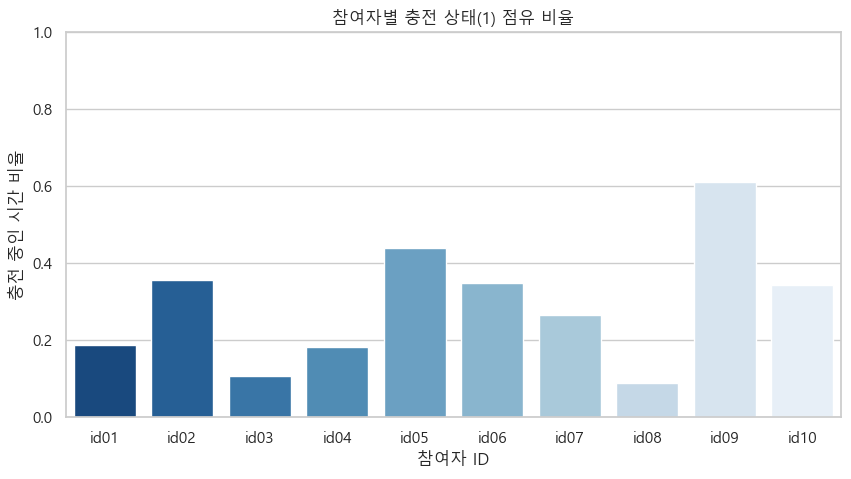

In [4]:
ac_ratio = df.groupby("subject_id")["m_charging"].mean().reset_index()
ac_ratio = ac_ratio.sort_values(by="subject_id")

plt.figure(figsize=(10, 5))
sns.barplot(data=ac_ratio, x="subject_id", y="m_charging", hue="subject_id", palette="Blues_r", legend=False)
plt.title("참여자별 충전 상태(1) 점유 비율")
plt.ylabel("충전 중인 시간 비율")
plt.xlabel("참여자 ID")
plt.ylim(0, 1)
plt.show()

## 3. 시간대별 충전 점유율 분석 (24시간 패턴)
하루 중 어느 시간대에 스마트폰을 주로 충전하는지 분석합니다. (주로 수면 시간에 높은 충전율을 보임)

In [5]:
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek

hourly_charging = df.groupby(["subject_id", "hour"])["m_charging"].mean().reset_index()

### 3.1 참여자 통합 시간대별 충전 비율 흐름

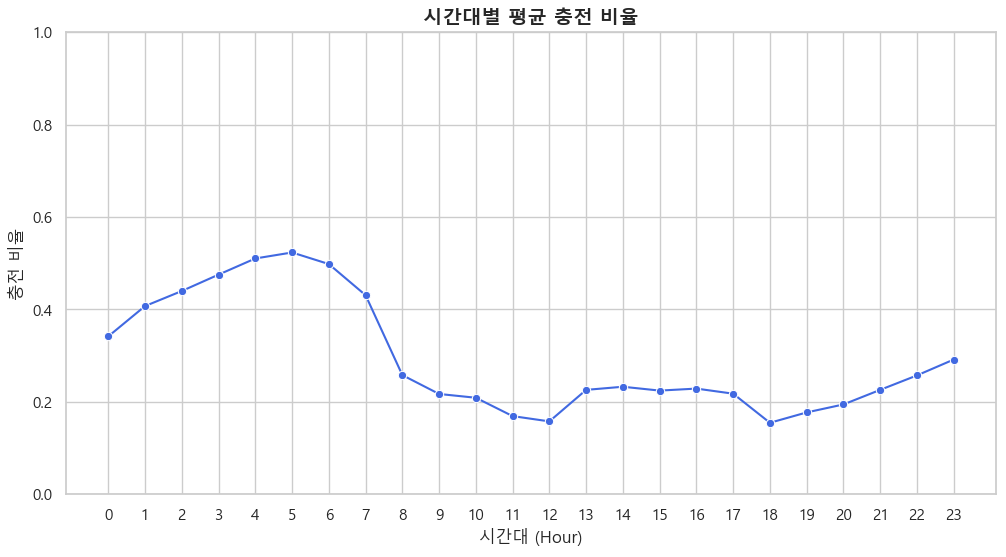

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_charging, x="hour", y="m_charging", errorbar=None, color="royalblue", marker="o")
plt.title("시간대별 평균 충전 비율", fontsize=14, fontweight="bold")
plt.xlabel("시간대 (Hour)")
plt.ylabel("충전 비율")
plt.xticks(range(0, 24))
plt.ylim(0, 1)
plt.show()

### 3.2 참여자별 시간대별 개별 충전 흐름 (영역 시각화)

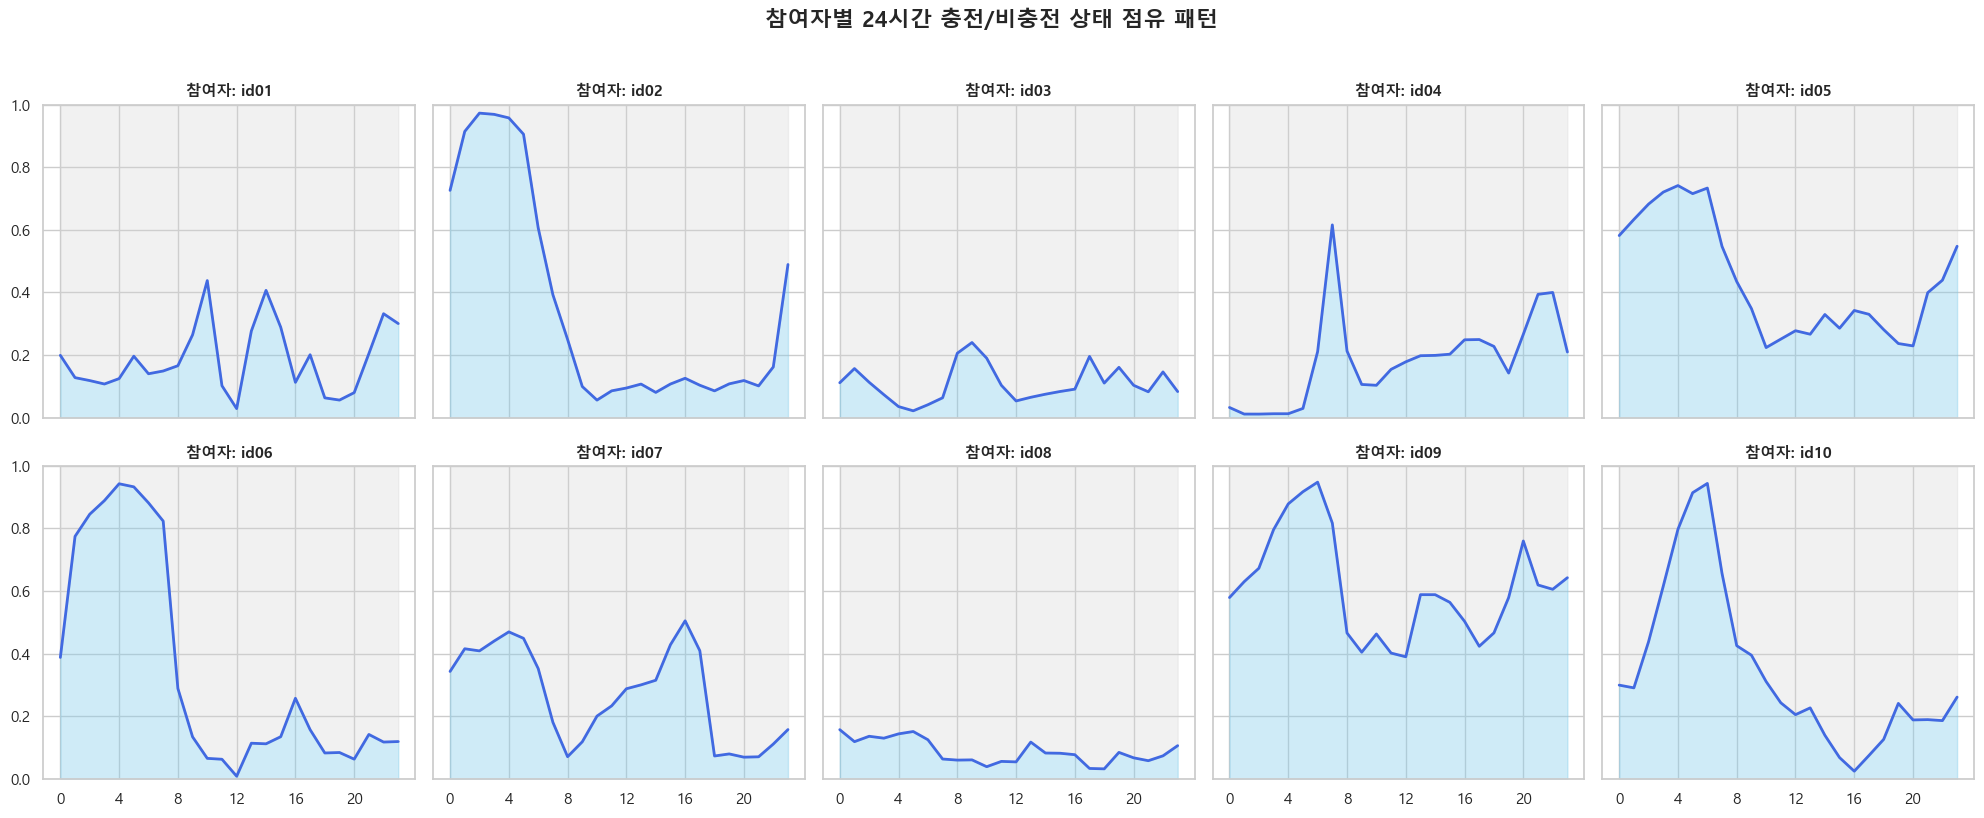

In [7]:
subjects = sorted(df["subject_id"].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sub in enumerate(subjects):
    sub_data = hourly_charging[hourly_charging["subject_id"] == sub]
    axes[idx].plot(sub_data["hour"], sub_data["m_charging"], color="royalblue", linewidth=2)
    axes[idx].fill_between(sub_data["hour"], 0, sub_data["m_charging"], color="skyblue", alpha=0.4, label="Charging")
    axes[idx].fill_between(sub_data["hour"], sub_data["m_charging"], 1, color="lightgray", alpha=0.3, label="Not Charging")
    axes[idx].set_title(f"참여자: {sub}", fontsize=11, fontweight="bold")
    axes[idx].set_xticks(range(0, 24, 4))
    axes[idx].set_ylim(0, 1)

plt.suptitle("참여자별 24시간 충전/비충전 상태 점유 패턴", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. 주말 vs 주중 충전 패턴 비교

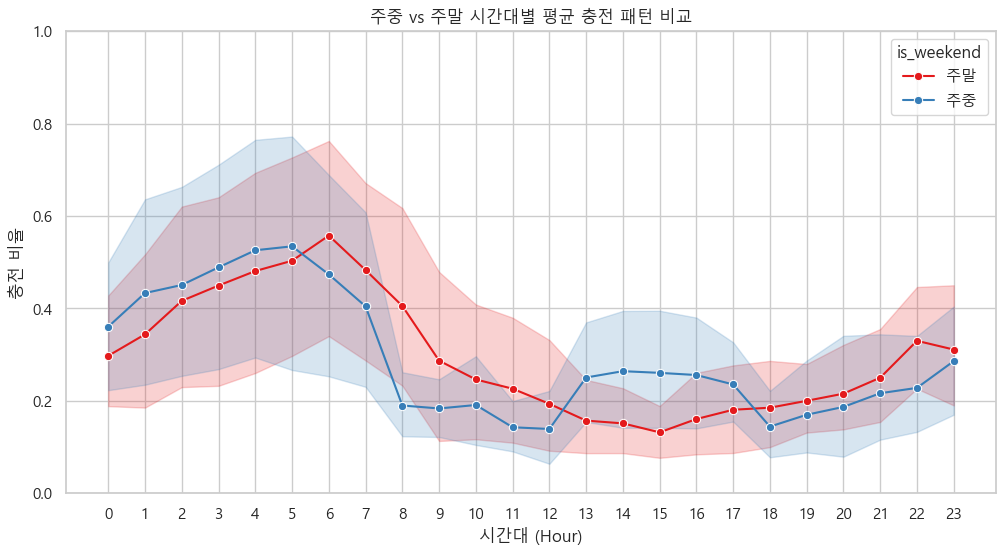

In [8]:
df["is_weekend"] = df["dayofweek"].isin([5, 6]).map({True: "주말", False: "주중"})
weekend_charging = df.groupby(["subject_id", "is_weekend", "hour"])["m_charging"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=weekend_charging, x="hour", y="m_charging", hue="is_weekend", palette="Set1", marker="o")
plt.title("주중 vs 주말 시간대별 평균 충전 패턴 비교")
plt.xlabel("시간대 (Hour)")
plt.ylabel("충전 비율")
plt.xticks(range(0, 24))
plt.ylim(0, 1)
plt.show()

## 5. 피처 엔지니어링 제안
* **`ac_charging_ratio`**: 하루 동안의 충전 시간 비율.
* **`ac_charging_sessions`**: 하루 동안 충전기가 연결된 횟수 (이벤트 세션 수).
* **`ac_night_charging_ratio`**: 수면 시간대(23시~07시)의 평균 충전 비율 (수면 예측 피처).